# 三维金（Au）超表面

运行四个代码单元格：检查 GPU、建立并运行仿真、显示二维场图、保存数据。材料、波源和几何参数集中在第二个代码单元格。

## 金的材料模型与物理尺度

采用 Rakić 等人的 **Lorentz–Drude（LD）金参数**，包含一个 Drude 极点和五个 Lorentz 极点，$\varepsilon_\infty=1$、$\hbar\omega_p=9.03\,\mathrm{eV}$。这是文献对实验光学常数的色散拟合，不是理想导体。

| 极点 | 振子强度 f | 共振能量 ℏω（eV） | 展宽 ℏΓ（eV） |
|---|---:|---:|---:|
| Drude | 0.760 | 0 | 0.053 |
| Lorentz 1 | 0.024 | 0.415 | 0.241 |
| Lorentz 2 | 0.010 | 0.830 | 0.345 |
| Lorentz 3 | 0.071 | 2.969 | 0.870 |
| Lorentz 4 | 0.601 | 4.304 | 2.494 |
| Lorentz 5 | 4.384 | 13.32 | 2.214 |

使用 exp(-iωt) 约定。与求解器参数的对应关系为：Drude 的 plasma_frequency = √f₀ ωp；Lorentz 的 delta_eps = fⱼ ωp²/ωⱼ²，omega_0 = ωⱼ，damping = Γⱼ/2。所有以 eV 表示的能量均通过 PhysicalScale 转换为归一化角频率，不能直接作为求解器频率输入。

默认一个长度单位为 **48 nm**，一个时间单位为 48 nm/c₀；中心真空波长为 **800 nm**，对应原来的归一化普通频率 0.06。原有几何对应周期 384 nm、金圆柱半径 115.2 nm、高度 144 nm；四倍细化后的网格间距为 12 nm。800 nm 处该模型的解析相对介电常数约为 **−20.2777 + 2.0706i**。

本示例用于演示金的色散仿真，未做几何和时间窗口的收敛研究。LD 是近似拟合；原论文指出贵金属的带间吸收用 BB 模型描述更合适。比较实验时应针对波段和具体样品验证模型，并仅在文献覆盖的波段解释宽带脉冲结果。

来源：A. D. Rakić et al., *Optical properties of metallic films for vertical-cavity optoelectronic devices*, Applied Optics **37**, 5271–5283 (1998)，表 1、表 2。 [论文 DOI](https://doi.org/10.1364/AO.37.005271) · [出版商参数表](https://opg.optica.org/ao/abstract.cfm?uri=ao-37-22-5271) · [论文全文](https://optiwave.com/wp-content/uploads/2015/06/4.pdf)


In [1]:
# 1. 系统与 GPU 检查
from pathlib import Path
import os
import sys

# 在导入 JAX 前设置，避免其一次性占用整张 GPU。
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")
import jax

def find_repo_root():
    configured = os.environ.get("FDTDZ_REPO_ROOT")
    candidates = [] if configured is None else [Path(configured)]
    candidates += [Path.cwd(), Path.cwd() / "fdtdz", *Path.cwd().parents]
    candidates += [Path("/mnt/e/imaginary-fdtdz/fdtdz"),
                   Path("E:/imaginary-fdtdz/fdtdz")]
    for candidate in candidates:
        if (candidate / "src" / "fdtdz_jax").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("找不到 src/fdtdz_jax；请在项目目录启动 Jupyter，或设置 FDTDZ_REPO_ROOT。")

REPO_ROOT = find_repo_root()
SOURCE_ROOT = str(REPO_ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

gpu_devices = [device for device in jax.devices()
               if device.platform in ("gpu", "cuda", "rocm")]
print("Python:", sys.executable)
print("JAX devices:", jax.devices())
if not gpu_devices:
    raise RuntimeError("当前 kernel 未检测到 GPU；请切换到安装了 GPU 版 JAX 的 kernel。")


Python: /mnt/e/imaginary-fdtdz/fdtdz/.venv-wsl/bin/python
JAX devices: [cuda(id=0)]


In [2]:
# 2. 材料、波源、几何与仿真（需要改模型时，只修改本单元格）
import numpy as np
import matplotlib.pyplot as plt
from fdtdz_jax import (
    BoundarySpec3D, CylinderZ3D, GridSpec3D, Layer3D,
    Lossless, Multipole, PhysicalScale, PlaneWaveSource3D,
    ScatteringMonitor3D, Simulation3D,
)

# Keep the original physical unit cell (8 x 8 x 96), then refine it.
# The former 8 x 8 transverse grid gave the cylinder only about five
# cells across; it was a spatial-resolution issue rather than a too-small
# physical simulation range.
BASE_GRID_SHAPE = (8, 8, 96)
GRID_REFINEMENT = 4
DT = 0.45
NUM_STEPS = 240
# Physical choices: the old source frequency 0.06 now corresponds to 800 nm.
LENGTH_UNIT_M = 48e-9
SOURCE_WAVELENGTH_M = 800e-9
physical_scale = PhysicalScale(length_unit_m=LENGTH_UNIT_M)
SOURCE_FREQUENCY = float(1.0 / physical_scale.wavelength(SOURCE_WAVELENGTH_M))
BASE_DISPLAY_Z_INDEX = 50  # x-y 截面，位于超表面附近
BASE_DISPLAY_SNAPSHOT_STEP = 120

def gaussian_pulse(num_steps, dt, frequency, center=18.0, width=6.0):
    time = np.arange(num_steps) * dt
    return np.exp(-0.5 * ((time - center) / width)**2) * np.sin(
        2.0 * np.pi * frequency * (time - center))

air = Lossless(1.0)
substrate = Lossless(2.25)
# Au: Rakić et al. (1998), Tables 1 and 2, Lorentz–Drude model.
# https://doi.org/10.1364/AO.37.005271
# Quoted energies are hbar*omega or hbar*Gamma in eV, not normalized rates.
GOLD_EPS_INF = 1.0
GOLD_PLASMA_ENERGY_EV = 9.03
GOLD_DRUDE_STRENGTH = 0.760
GOLD_DRUDE_WIDTH_EV = 0.053
GOLD_LORENTZ_PARAMETERS = (
    # (oscillator strength f_j, resonance energy eV, full width eV)
    (0.024, 0.415, 0.241),
    (0.010, 0.830, 0.345),
    (0.071, 2.969, 0.870),
    (0.601, 4.304, 2.494),
    (4.384, 13.32, 2.214),
)
gold = Multipole(GOLD_EPS_INF, (
    physical_scale.drude_pole_from_ev(
        plasma_energy_ev=np.sqrt(GOLD_DRUDE_STRENGTH) * GOLD_PLASMA_ENERGY_EV,
        collision_energy_ev=GOLD_DRUDE_WIDTH_EV),
    *(physical_scale.lorentz_pole_from_ev(
        delta_eps=strength * (GOLD_PLASMA_ENERGY_EV / resonance_ev)**2,
        resonance_energy_ev=resonance_ev,
        damping_delta_energy_ev=width_ev / 2.0)
      for strength, resonance_ev, width_ev in GOLD_LORENTZ_PARAMETERS),
))
source_omega = 2.0 * np.pi * SOURCE_FREQUENCY
gold_eps_at_source = complex(gold.relative_permittivity(source_omega))
print(f"Au at {SOURCE_WAVELENGTH_M * 1e9:.0f} nm: "
      f"epsilon_r = {gold_eps_at_source.real:.4f} "
      f"+ {gold_eps_at_source.imag:.4f}i")
waveform = gaussian_pulse(NUM_STEPS, DT, SOURCE_FREQUENCY)

base_simulation = Simulation3D(
    GridSpec3D(shape=BASE_GRID_SHAPE, spacing=(1.0, 1.0, 1.0), dt=DT),
    BoundarySpec3D(cpml_width=12, target_reflection=1e-8),
    background=air, backend="jax", dtype=np.float32)
base_simulation.add_material("substrate", substrate)
base_simulation.add_material("gold", gold)
base_simulation.add_geometry(Layer3D(z_min=47.0, z_max=50.0, material="substrate"))
base_simulation.add_geometry(CylinderZ3D(
    center_xy=(4.0, 4.0), radius=2.4, z_center=48.5, height=3.0,
    material="gold"))
base_simulation.set_source(PlaneWaveSource3D(
    waveform, z_index=20, polarization_xy=(1.0, 0.0), direction=1))
base_simulation.set_monitors(ScatteringMonitor3D(
    reflection_z=32, transmission_z=72,
    snapshot_steps=(BASE_DISPLAY_SNAPSHOT_STEP,)))

# Refine every axis and time step together, preserving the physical domain,
# geometry, source timing, and monitor locations.  The plotted x-y plane is
# now 32 x 32 samples, and the gold cylinder is about 19 cells in diameter.
simulation = base_simulation.refined(GRID_REFINEMENT)
DISPLAY_Z_INDEX = BASE_DISPLAY_Z_INDEX * GRID_REFINEMENT
DISPLAY_SNAPSHOT_STEP = BASE_DISPLAY_SNAPSHOT_STEP * GRID_REFINEMENT
result = simulation.run(window="hann")


Au at 800 nm: epsilon_r = -20.2777 + 2.0706i


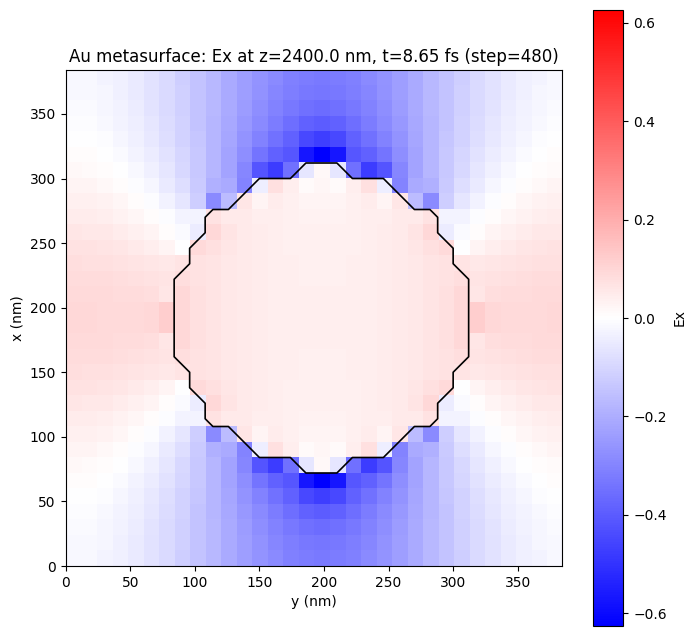

In [3]:
# 3. 最终结果：与 welcome-to-fdtd-z.ipynb 相同风格的二维场图
field = result.snapshot_field("Ex")[0, :, :, DISPLAY_Z_INDEX]
field_limit = max(float(np.max(np.abs(field))), np.finfo(float).eps)
extent = (0.0, float(physical_scale.metres(result.grid.extent[1])) * 1e9,
          0.0, float(physical_scale.metres(result.grid.extent[0])) * 1e9)
gold_id = result.material_names.index("gold")
gold_mask = result.material_ids[0, :, :, DISPLAY_Z_INDEX] == gold_id

plt.figure(figsize=(8, 8))
field_image = plt.imshow(field, origin="lower", aspect="equal", cmap="bwr",
           vmin=-field_limit, vmax=field_limit, extent=extent,
           interpolation="none")
plt.contour(gold_mask, levels=(0.5,), colors="black", linewidths=1.2,
            origin="lower", extent=extent)
plt.colorbar(field_image, label="Ex")
plt.xlabel("y (nm)")
plt.ylabel("x (nm)")
plt.title(
    f"Au metasurface: Ex at z="
    f"{float(physical_scale.metres(DISPLAY_Z_INDEX * result.grid.dz)) * 1e9:.1f} nm, "
    f"t={float(physical_scale.seconds(result.snapshot_times[0])) * 1e15:.2f} fs "
    f"(step={DISPLAY_SNAPSHOT_STEP})")
plt.show()


In [5]:
# 4. 保存结果
OUTPUT_DIRECTORY = REPO_ROOT / "outputs"
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
output_file = OUTPUT_DIRECTORY / "metasurface_3d_result.npz"
np.savez_compressed(
    output_file,
    # Numeric fields retain solver units; these metadata define their SI scale.
    length_unit_m=LENGTH_UNIT_M,
    time_unit_s=physical_scale.time_unit_s,
    grid_spacing=np.asarray(result.grid.spacing),
    dt=result.grid.dt,
    source_wavelength_m=SOURCE_WAVELENGTH_M,
    material_names=np.asarray(result.material_names),
    gold_model="Rakic_1998_LD",
    gold_reference_doi="10.1364/AO.37.005271",
    gold_eps_inf=GOLD_EPS_INF,
    gold_plasma_energy_ev=GOLD_PLASMA_ENERGY_EV,
    gold_drude_strength=GOLD_DRUDE_STRENGTH,
    gold_drude_width_ev=GOLD_DRUDE_WIDTH_EV,
    gold_lorentz_parameters=np.asarray(GOLD_LORENTZ_PARAMETERS),
    material_ids=result.material_ids,
    final_electric=result.final_state.electric,
    final_magnetic=result.final_state.magnetic,
    final_displacement=result.final_state.displacement,
    final_polarization=result.final_polarization(),
    snapshot_steps=result.snapshots.steps,
    snapshot_electric=result.snapshots.electric,
    snapshot_displacement=result.snapshots.displacement,
    snapshot_polarization=result.snapshots.polarization,
)
print("已保存:", output_file)


已保存: /mnt/e/imaginary-fdtdz/fdtdz/outputs/metasurface_3d_result.npz
